In [1]:
import pandas as pd
import seaborn as sn
import matplotlib as mt
import numpy as np

In [2]:
#Importing the raw dataset
df = pd.read_csv('Raw data.csv')
df.head()

,Timestamp,How many people reside in your household?,What is your marital status?,Employment status,What is your educational background?,What is your age (in years)?,What is your gender?,Column 7,What is your marital status?.1,Employment status.1,...,Would better access to price information help you plan your food purchases more effectively?,Do you believe government or local authorities are doing enough to control food price fluctuations?,"In your opinion, what is the main reason for fruit and vegetable price fluctuations?",Do you compare prices from different sellers before buying fruits and vegetables?,What is your age in years?,Column 27,Column 25,Column 19,Column 14,Column 12
0,6/23/2025 13:18:35,NaN,NaN,NaN,NaN,NaN,Female,NaN,Single,Unemployed,...,Yes,No,Climate-related factors,Always,24,NaN,NaN,NaN,NaN,NaN
1,6/23/2025 13:18:40,NaN,NaN,NaN,NaN,NaN,Female,NaN,Single,Unemployed,...,Yes,No,Climate-related factors,Always,24,NaN,NaN,NaN,NaN,NaN
2,6/23/2025 13:29:11,NaN,NaN,NaN,NaN,NaN,Male,NaN,Single,Unemployed,...,Yes,No,Climate-related factors,Sometimes,28,NaN,NaN,NaN,NaN,NaN
3,6/23/2025 13:47:07,NaN,NaN,NaN,NaN,NaN,Male,NaN,Single,Unemployed,...,Yes,No,Seasonal changes,Sometimes,24,NaN,NaN,NaN,NaN,NaN
4,6/23/2025 14:51:27,NaN,NaN,NaN,NaN,NaN,Male,NaN,Single,Self- employed,...,Yes,Not Sure,Seasonal changes,Rarely,22,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 37 columns):
 #   Column                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                            --------------  -----  
 0   Timestamp                                                                                                         52 non-null     object 
 1   How many people reside in your household?                                                                         0 non-null      float64
 2   What is your marital status?                                                                                      0 non-null      float64
 3   Employment status                                                                                                 0 non-null      float64
 4   What is your educational backgroun

## Preprocessing
As seen above the data is too messy, so I will removing columns with no entries and renaming the remaining ones so they can be easy to work with.

In [4]:
del df['How many people reside in your household?']
del df['What is your marital status?']
del df['Employment status']
del df['What is your educational background?']
del df['What is your age (in years)?']
del df['Column 7']
del df['Column 27']
del df['Column 25']
del df['Column 19']
del df['Column 14']
del df['Column 12']
del df['Timestamp']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 25 columns):
 #   Column                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                            --------------  -----  
 0   What is your gender?                                                                                              52 non-null     object 
 1   What is your marital status?.1                                                                                    52 non-null     object 
 2   Employment status.1                                                                                               52 non-null     object 
 3   How many people reside in your house?                                                                             52 non-null     object 
 4   What is your level education      

In [6]:
df.rename(columns={'What is your gender?':'Gender',
                  'What is your marital status?.1':'Marital Status',
                  'Employment status.1':'Employment status',
                  'How many people reside in your house?':'Household Size',
                  'What is your level education':'Level of education',
                  'Do you have access to credit?':'Credit Access',
                  'Do u have access to transport':'Transport access',
                  'Average Monthly Household Income':'Household Income',
                  'Does your household receive any social grants?':'Social grants',
                  'Distance to Nearest Market Where You Buy Fruits and Vegetables (in km):':'Distance to Market',
                  'What type of market do you usually buy fruits and vegetables from?':'Type of market',
                  'What is your primary source of price information?':'Information Source',
                  'Have fruit and vegetable prices increased in the past year?':'Fruit & Veg Prices increased',
                  'What coping strategies have you used to deal with price increases?':'Coping strategies',
                  'How effective have these coping strategies been?':'Effectiveness of Coping Strategies',
                  'Do you believe you need additional support to cope with rising fruit and vegetable prices?':'Need for Support',
                  'How many times does your household consume fruits in a typical week?':'Consumption of fruits frequency',
                  'Has your household reduced the quantity of fruits and vegetables consumed in the past year due to price changes?':'Reduced Fruit & Veg Intake?',
                  'Which fruit is the most commonly consumed in your household?':'Most consumed fruit',
                  'Which Vegetable is the most commonly consumed in your household?':'Most consumed Vegetable',
                  'Would better access to price information help you plan your food purchases more effectively?':'Will Better Price Info help?',
                  'Do you believe government or local authorities are doing enough to control food price fluctuations?':'Govt Price Control?',
                  'In your opinion, what is the main reason for fruit and vegetable price fluctuations?':'Main Price Fluctuation Cause?',
                  'Do you compare prices from different sellers before buying fruits and vegetables?':'Compare Seller Prices?',
                  'What is your age in years?':'Age'}, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Gender                              52 non-null     object 
 1   Marital Status                      52 non-null     object 
 2   Employment status                   52 non-null     object 
 3   Household Size                      52 non-null     object 
 4   Level of education                  52 non-null     object 
 5   Credit Access                       52 non-null     object 
 6   Transport access                    52 non-null     object 
 7   Household Income                    52 non-null     object 
 8   Social grants                       52 non-null     object 
 9   Distance to Market                  52 non-null     float64
 10  Type of market                      52 non-null     object 
 11  Information Source                  52 non-null

## Further Preprocessing
- Converting columns to their correct measurement scale
- Running descreptive Statistics
- Removing redundant variables and treating outliers


In [8]:
#Household Size is not saved as integer because it probably has a string, so we deal with the string before converting it
df['Household Size']

0                                                     4
1                                                     3
2                                                     4
3                                                     6
4                                                     1
5                                                     5
6                                                     4
7                                                     6
8     I don't have a house.my parents do and it hous...
9                                                     8
10                                                    2
11                                                    7
12                                                    5
13                                                    6
14                                                    4
15                                                    5
16                                                    5
17                                              

In [9]:
#Culprit found on index 8
df['Household Size'].loc[8]

"I don't have a house.my parents do and it houses them and thier kids, and the result is 8"

In [10]:
df['Household Size']=df['Household Size'].replace({"I don't have a house.my parents do and it houses them and thier kids, and the result is 8": 8})
df['Household Size']

0     4
1     3
2     4
3     6
4     1
5     5
6     4
7     6
8     8
9     8
10    2
11    7
12    5
13    6
14    4
15    5
16    5
17    4
18    3
19    3
20    4
21    5
22    3
23    2
24    6
25    3
26    3
27    2
28    4
29    7
30    5
31    1
32    8
33    1
34    7
35    4
36    5
37    3
38    8
39    3
40    5
41    5
42    8
43    5
44    1
45    5
46    4
47    8
48    6
49    7
50    5
51    6
Name: Household Size, dtype: object

In [11]:
df['Household Size']= df['Household Size'].astype(int)

In [12]:
#Age also has a string
df['Age']

0           24
1           24
2           28
3           24
4           22
5           23
6           24
7           25
8           23
9           22
10          23
11    21 years
12          22
13          23
14          23
15          26
16          23
17          23
18          22
19          23
20          46
21          34
22          20
23          24
24          26
25          23
26          53
27          25
28          36
29          23
30          38
31          27
32          50
33          22
34          24
35          22
36          18
37          22
38          55
39          25
40          48
41          19
42          23
43          45
44          23
45          20
46          21
47          59
48          24
49          35
50          46
51          52
Name: Age, dtype: object

In [13]:
df['Age']=df['Age'].replace({'21 years':21})
df['Age']=df['Age'].astype(int)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Gender                              52 non-null     object 
 1   Marital Status                      52 non-null     object 
 2   Employment status                   52 non-null     object 
 3   Household Size                      52 non-null     int64  
 4   Level of education                  52 non-null     object 
 5   Credit Access                       52 non-null     object 
 6   Transport access                    52 non-null     object 
 7   Household Income                    52 non-null     object 
 8   Social grants                       52 non-null     object 
 9   Distance to Market                  52 non-null     float64
 10  Type of market                      52 non-null     object 
 11  Information Source                  52 non-null

## Outlier treatment

In [15]:
df.describe()

,Household Size,Distance to Market,Age
count,52.000000,52.000000,52.000000
mean,4.653846,15.717308,28.769231
std,1.989035,68.836264,10.880123
min,1.000000,0.500000,18.000000
25%,3.000000,2.000000,22.750000
50%,5.000000,5.000000,24.000000
75%,6.000000,8.200000,29.500000
max,8.000000,500.000000,59.000000


<Axes: ylabel='Distance to Market'>

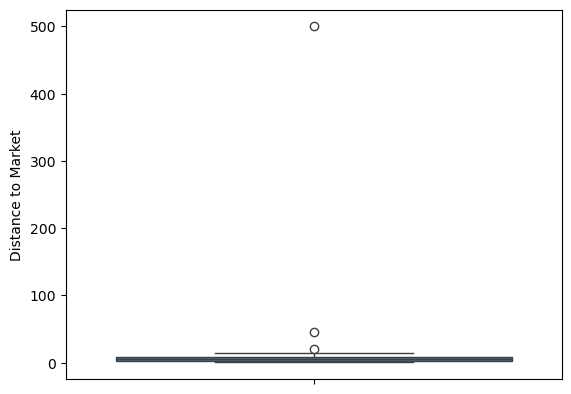

In [16]:
sn.boxplot(df['Distance to Market'])


500 is an extreme outlier for Distance to market, which might be due to confusion of measurement unit by the interviewee, hence I'm converting it to meters


In [17]:
df.loc[df['Distance to Market'] == 500, 'Distance to Market'] = 0.5


## X-Y split & dummy variable creation

In [18]:
x = df.drop('Coping strategies', axis=1)
y = df['Coping strategies']

In [19]:
x = pd.get_dummies(x, drop_first=True, dtype=int)

In [20]:
#Multinomial Logistic Regression works with numerical target variable so we are converting y categories into numerics
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

## Train-test split

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,train_size=0.8, random_state= 0)

## Multinomial Logistic Regression Training

In [23]:
from sklearn.linear_model import LogisticRegression

mylog_model = LogisticRegression(multi_class='multinomial',max_iter=1000)

In [24]:
mylog_model.fit(x_train, y_train)

C:\Users\tebog\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

## Model evaluation
Lastly I will make predictions using test data, then use the predictions to see accuracy of the model

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [26]:
y_pred= mylog_model.predict(x_test)

In [27]:
accuracy_score(y_test, y_pred)

0.2727272727272727

In [28]:
confusion_matrix(y_test, y_pred)

array([[1, 3, 0, 1],
       [1, 2, 0, 2],
       [1, 0, 0, 0],
       [0, 0, 0, 0]])

The relatively low predictive accuracy of the multinomial logistic regression model may largely be attributed to the small sample size, which limited the model’s ability to learn clear patterns and relationships between household characteristics and coping strategy choices